
===== CZĘŚĆ 1: Analiza wrażliwości k =====
Najlepsze k: 6 (accuracy = 0.9583)
Wynik Leave-One-Out (n=120): 0.9500


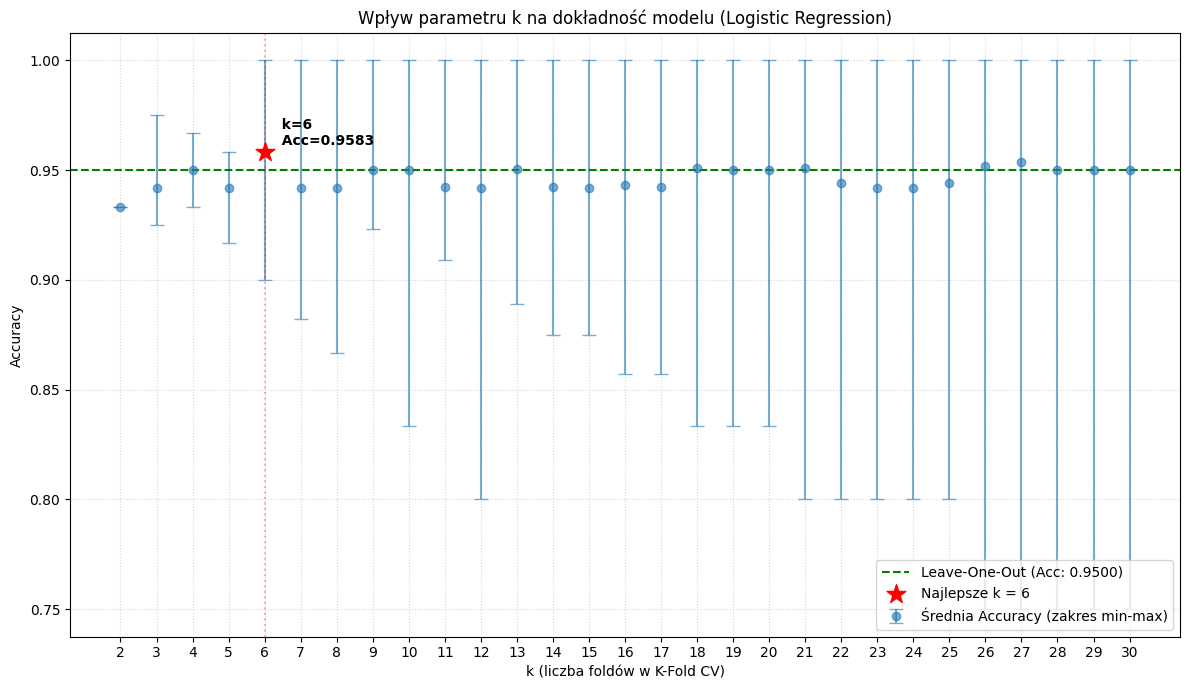


===== CZĘŚĆ 2: Porównanie strategii CV =====

--- KNN (cv=3) ---
KFold: mean=0.8333
StratifiedKFold: mean=0.8167
ShuffleSplit: mean=0.8426

Najlepsze CV dla KNN (cv=3): ShuffleSplit

--- Wszystkie modele (cv=5) ---

Model: LogisticRegression
KFold: mean=0.9417, var=0.000417
StratifiedKFold: mean=0.9500, var=0.002361
ShuffleSplit: mean=0.9556, var=0.000802

Model: KNN
KFold: mean=0.8500, var=0.005972
StratifiedKFold: mean=0.8333, var=0.015972
ShuffleSplit: mean=0.8222, var=0.000802

Model: SVC
KFold: mean=0.7667, var=0.010139
StratifiedKFold: mean=0.7667, var=0.011528
ShuffleSplit: mean=0.7389, var=0.001111

Model: DecisionTree
KFold: mean=0.9083, var=0.000278
StratifiedKFold: mean=0.8333, var=0.001389
ShuffleSplit: mean=0.8611, var=0.000309

Najlepsze CV dla modeli (cv=5):
LogisticRegression: ShuffleSplit (accuracy=0.9556)
KNN: KFold (accuracy=0.8500)
SVC: KFold (accuracy=0.7667)
DecisionTree: KFold (accuracy=0.9083)

===== CZĘŚĆ 3: SVM kernels =====

--- Kernel: linear ---
Test accur

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    KFold, LeaveOneOut, cross_val_score,
    StratifiedKFold, ShuffleSplit, train_test_split
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm

# =========================
# Wczytanie danych
# =========================

data = pd.read_csv('VLagun_Phys_Years3.csv')

X = data.iloc[:, :8]
y = data.iloc[:, 8]

# =========================
# CZĘŚĆ 1: Analiza wrażliwości k
# =========================
print("\n===== CZĘŚĆ 1: Analiza wrażliwości k =====")

model = LogisticRegression(max_iter=1000)

# Leave-One-Out (punkt odniesienia)
loo = LeaveOneOut()
loo_scores = cross_val_score(model, X, y, cv=loo, scoring='accuracy')
ideal_score = loo_scores.mean()

k_values = list(range(2, 31))
means, mins, maxs = [], [], []

for k in k_values:
    kf = KFold(n_splits=k, shuffle=True, random_state=1)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

    means.append(scores.mean())
    mins.append(scores.min())
    maxs.append(scores.max())

# Wyznaczenie najlepszego k
best_idx = np.argmax(means)
best_k = k_values[best_idx]
best_score = means[best_idx]

print(f"Najlepsze k: {best_k} (accuracy = {best_score:.4f})")
print(f"Wynik Leave-One-Out (n={len(X)}): {ideal_score:.4f}")

# --- WYKRES ANALIZY WRAŻLIWOŚCI ---
plt.figure(figsize=(12, 7))

# Słupki błędów pokazujące zakres min-max dla każdego k
plt.errorbar(k_values, means,
             yerr=[np.array(means)-np.array(mins), np.array(maxs)-np.array(means)],
             fmt='o', capsize=5, label='Średnia Accuracy (zakres min-max)',
             color='#1f77b4', alpha=0.6)

# Linia pozioma dla wyniku idealnego (LOO)
plt.axhline(y=ideal_score, color='green', linestyle='--',
            label=f'Leave-One-Out (Acc: {ideal_score:.4f})')

# --- ZAZNACZENIE NAJLEPSZEGO WYNIKU ---
plt.scatter(best_k, best_score, color='red', s=200, marker='*',
            label=f'Najlepsze k = {best_k}', zorder=5)
plt.axvline(x=best_k, color='red', linestyle=':', alpha=0.3)

# Dodanie opisu bezpośrednio przy punkcie
plt.annotate(f'  k={best_k}\n  Acc={best_score:.4f}',
             xy=(best_k, best_score),
             textcoords="offset points",
             xytext=(5,5),
             fontweight='bold')

plt.xlabel('k (liczba foldów w K-Fold CV)')
plt.ylabel('Accuracy')
plt.title('Wpływ parametru k na dokładność modelu (Logistic Regression)')
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# =========================
# CZĘŚĆ 2: Porównanie strategii CV
# =========================
print("\n===== CZĘŚĆ 2: Porównanie strategii CV =====")

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(),
    "DecisionTree": DecisionTreeClassifier()
}

# --- KNN (cv=3) ---
print("\n--- KNN (cv=3) ---")

cv_methods_3 = {
    "KFold": KFold(n_splits=3, shuffle=True, random_state=1),
    "StratifiedKFold": StratifiedKFold(n_splits=3, shuffle=True, random_state=1),
    "ShuffleSplit": ShuffleSplit(n_splits=3, test_size=0.3, random_state=1)
}

knn_results = {}

for name, cv in cv_methods_3.items():
    scores = cross_val_score(KNeighborsClassifier(), X, y, cv=cv, scoring='accuracy')
    knn_results[name] = scores.mean()
    print(f"{name}: mean={scores.mean():.4f}")

best_knn_cv = max(knn_results, key=knn_results.get)
print(f"\nNajlepsze CV dla KNN (cv=3): {best_knn_cv}")

# --- Wszystkie modele (cv=5) ---
print("\n--- Wszystkie modele (cv=5) ---")

cv_methods_5 = {
    "KFold": KFold(n_splits=5, shuffle=True, random_state=1),
    "StratifiedKFold": StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    "ShuffleSplit": ShuffleSplit(n_splits=5, test_size=0.3, random_state=1)
}

results_summary = {}

for model_name, model_obj in models.items():
    print(f"\nModel: {model_name}")
    results_summary[model_name] = {}

    for cv_name, cv in cv_methods_5.items():
        scores = cross_val_score(model_obj, X, y, cv=cv, scoring='accuracy')
        mean = scores.mean()
        var = scores.var()
        results_summary[model_name][cv_name] = mean
        print(f"{cv_name}: mean={mean:.4f}, var={var:.6f}")

# podsumowanie globalne
all_best = []
for model_name, res in results_summary.items():
    best_cv = max(res, key=res.get)
    all_best.append((model_name, best_cv, res[best_cv]))

print("\nNajlepsze CV dla modeli (cv=5):")
for model_name, cv, score in all_best:
    print(f"{model_name}: {cv} (accuracy={score:.4f})")

# =========================
# CZĘŚĆ 3: SVM kernels
# =========================
print("\n===== CZĘŚĆ 3: SVM kernels =====")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

kernels = ['linear', 'poly', 'rbf', 'sigmoid']

for kernel in kernels:
    print(f"\n--- Kernel: {kernel} ---")

    clf = svm.SVC(C=1, kernel=kernel)
    clf.fit(X_train, y_train)

    test_acc = clf.score(X_test, y_test)
    print(f"Test accuracy: {test_acc:.4f}")

    # CV metody
    cv_results = {}

    # standard cv=5
    scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
    cv_results['cv=5'] = scores.mean()
    print(f"cv=5 accuracy: {scores.mean():.4f}, std={scores.std():.4f}")

    # f1
    scores_f1 = cross_val_score(clf, X, y, cv=5, scoring='f1_macro')
    print(f"cv=5 f1_macro: {scores_f1.mean():.4f}")

    # ShuffleSplit
    ss = ShuffleSplit(n_splits=5, test_size=0.3, random_state=0)
    scores_ss = cross_val_score(clf, X, y, cv=ss, scoring='accuracy')
    cv_results['ShuffleSplit'] = scores_ss.mean()
    print(f"ShuffleSplit: {scores_ss.mean():.4f}, std={scores_ss.std():.4f}")

    # StratifiedKFold
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    scores_skf = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')
    cv_results['StratifiedKFold'] = scores_skf.mean()
    print(f"StratifiedKFold: {scores_skf.mean():.4f}, std={scores_skf.std():.4f}")

    # najlepsza metoda
    best_cv = max(cv_results, key=cv_results.get)
    print(f"Najlepsza metoda CV dla kernel={kernel}: {best_cv}")